In [25]:
#Task 1

import pandas as pd
import numpy as np

df = pd.read_csv("scores.csv")

X = df['hours'].values
y = df['scores'].values

print("Hours (X):\n", X)
print("\nScores (y):\n", y)

def calculate_coefficients(X, y):
    n = len(X)

    sum_x = np.sum(X)
    sum_y = np.sum(y)
    sum_x_sq = np.sum(X**2)
    sum_xy = np.sum(X * y)

    # Denominator for both formulas
    denominator = (n * sum_x_sq) - (sum_x)**2

    # Using formulas from the document
    B0 = ((sum_x_sq * sum_y) - (sum_x * sum_xy)) / denominator   # intercept (a)
    B1 = ((n * sum_xy) - (sum_x * sum_y)) / denominator          # slope (B)

    return B0, B1

B0, B1 = calculate_coefficients(X, y)

print(f"\nIntercept (B0): {B0:.2f}")
print(f"Slope (B1): {B1:.2f}")

def predict(x, B0, B1):
    return B0 + B1 * x

prediction1 = predict(5.5, B0, B1)
prediction2 = predict(9, B0, B1)

print(f"\nPrediction for 5.5 hours: {prediction1:.2f}")
print(f"Prediction for 9 hours: {prediction2:.2f}")

Hours (X):
 [ 1  2  3  4  5  6  7  8  9 10]

Scores (y):
 [35 40 50 55 60 65 70 75 85 95]

Intercept (B0): 28.67
Slope (B1): 6.24

Prediction for 5.5 hours: 63.00
Prediction for 9 hours: 84.85


In [26]:
#Task 2
from sklearn.linear_model import LinearRegression

x = df[['hours']]
y = df['scores']

model = LinearRegression()
model.fit(x,y)

B0_model = model.intercept_
B1_model = model.coef_[0]

print(f"Intercept(B0): {B0_model:.2f}")
print(f"Slope(B1): {B1_model:.2f}")

prediction1 = model.predict(pd.DataFrame([[5.5]], columns=['hours']))      #wrapping in dataframe to avoid warning
prediction2 = model.predict(pd.DataFrame([[9]], columns=['hours']))

print(f"\nPrediction for 5.5 hours: {prediction1[0]:.2f}")
print(f"Prediction for 9 hours: {prediction2[0]:.2f}")


Intercept(B0): 28.67
Slope(B1): 6.24

Prediction for 5.5 hours: 63.00
Prediction for 9 hours: 84.85


In [27]:
#Task 3
#The coefficients and predictions for both models are exaclty the same and this means that our 
#method of implementing linear regression from scratch was accurate. Both methods give 63.00 for 5.5 hours 
#and 84.85 for 9 hours which shows that both methods produce identical regression lines.

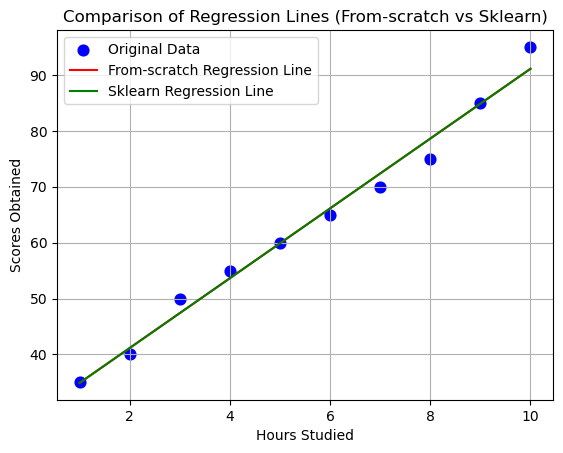

In [28]:
#Task 4
import matplotlib.pyplot as plt

y_manual_prediction = predict(X, B0, B1)

y_model_prediction = model.predict(pd.DataFrame(X, columns=['hours']))

plt.scatter(X, y, color='blue', label='Original Data', s=60)

# 2) Regression line (from-scratch)
plt.plot(X, y_manual_prediction, color='red', label='From-scratch Regression Line')

# 3) Regression line (scikit-learn)
plt.plot(X, y_model_prediction, color='green', label='Sklearn Regression Line')

# Add labels and title
plt.title('Comparison of Regression Lines (From-scratch vs Sklearn)')
plt.xlabel('Hours Studied')
plt.ylabel('Scores Obtained')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = df[['hours']]
y = df['scores']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training data points:", len(X_train))
print("Testing data points:", len(X_test))

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print("Actual test scores:", list(y_test.values.tolist()))   #tolist function is used to covert numpy values to numbers 
print("Predicted test scores:", [round(float(p), 2) for p in y_pred])
print(f"\nMean Squared Error (MSE): {mse:.2f}")

Training data points: 7
Testing data points: 3
Actual test scores: [85, 40, 65]
Predicted test scores: [84.91, 41.68, 66.39]

Mean Squared Error (MSE): 1.59
